In [15]:
# File: Homework 9

In [16]:
# 2.1 - Collect the Data

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

In [18]:
df = pd.read_csv("../../course_assignments/homework9/noisy_curvefit_data.csv")

In [19]:
print("Shape:", df.shape)
print("There are 100 rows and 6 columns.")
display(df.head())
display(df.tail())
print("Columns:", df.columns.tolist())

Shape: (100, 6)
There are 100 rows and 6 columns.


,x,y_noise_1,y_noise_2,y_noise_3,y_noise_4,y_noise_5
0,-1.000000,11.624419,8.296963,12.201067,7.811725,3.155566
1,-0.929293,10.377466,9.674440,12.198084,8.275006,7.518855
2,-0.858586,10.585100,9.251983,13.186565,12.926586,9.963630
3,-0.787879,10.913928,7.786344,12.552304,11.832379,9.625801
4,-0.717172,8.640287,8.551869,4.741432,8.790834,6.624113


,x,y_noise_1,y_noise_2,y_noise_3,y_noise_4,y_noise_5
95,5.717172,-1.411918,0.822231,-2.027132,-1.825106,2.746147
96,5.787879,0.344879,-1.718956,2.747559,-6.803779,-5.137472
97,5.858586,0.307133,0.353528,0.967976,5.461567,-0.905616
98,5.929293,0.048657,0.159961,2.482130,-0.414616,-4.334548
99,6.000000,-0.193438,-2.244792,1.930035,4.992414,-6.872850


Columns: ['x', 'y_noise_1', 'y_noise_2', 'y_noise_3', 'y_noise_4', 'y_noise_5']


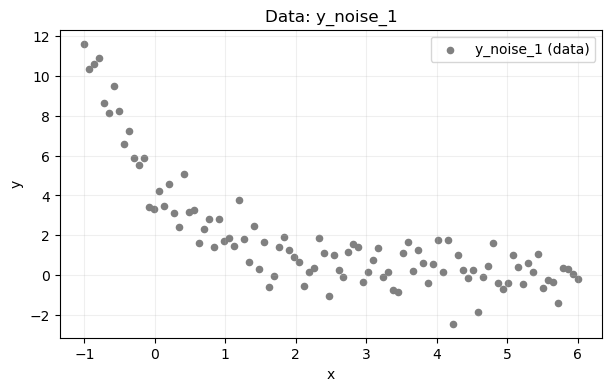

In [20]:
x = df['x'].values
y_noise_1 = df['y_noise_1'].values
plt.figure(figsize=(7,4))
plt.scatter(x, y_noise_1, label='y_noise_1 (data)', color='gray', s=20)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Data: y_noise_1')
plt.legend()
plt.grid(alpha=0.2)
plt.show()

In [21]:
# 2.2 - Fit the Data

In [25]:
def model(x, A, k):
    return A * np.exp(-k * x)

p0 = [1.0, 1.0]
popt, pcov = curve_fit(model, x, y_noise_1, p0=p0)
A_fit, k_fit = popt
print(f"Fit: y = {A_fit:.2f} * e^(-{k_fit:.2f} * x)")

residuals = y_noise_1 - model(x, A_fit, k_fit)
chi2 = np.sum(residuals**2)
dof = len(x) - len(popt)
chi2_reduced = chi2 / dof
print(f"Reduced chi-squared: {chi2_reduced:.4f}")

Fit: y = 4.71 * e^(-0.92 * x)
Reduced chi-squared: 0.7907


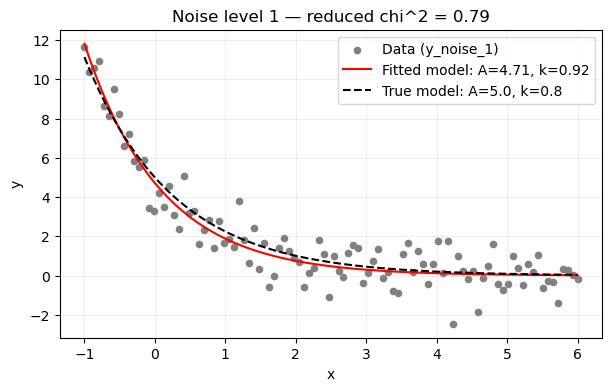

In [28]:
x_plot = np.linspace(x.min(), x.max(), 300)
true_model = model(x_plot, 5.0, 0.8) 

plt.figure(figsize=(7,4))
plt.scatter(x, y_noise_1, label='Data (y_noise_1)', color='gray', s=20)
plt.plot(x_plot, model(x_plot, A_fit, k_fit), 'r-', label=f'Fitted model: A={A_fit:.2f}, k={k_fit:.2f}')
plt.plot(x_plot, true_model, linestyle='--', color='k', label='True model: A=5.0, k=0.8')
plt.xlabel('x')
plt.ylabel('y')
plt.title(f'Noise level 1 — reduced chi^2 = {chi2_reduced:.2f}')
plt.legend()
plt.grid(alpha=0.2)
plt.show()


In [30]:
# 2.3 - Compare Different Noise Levels

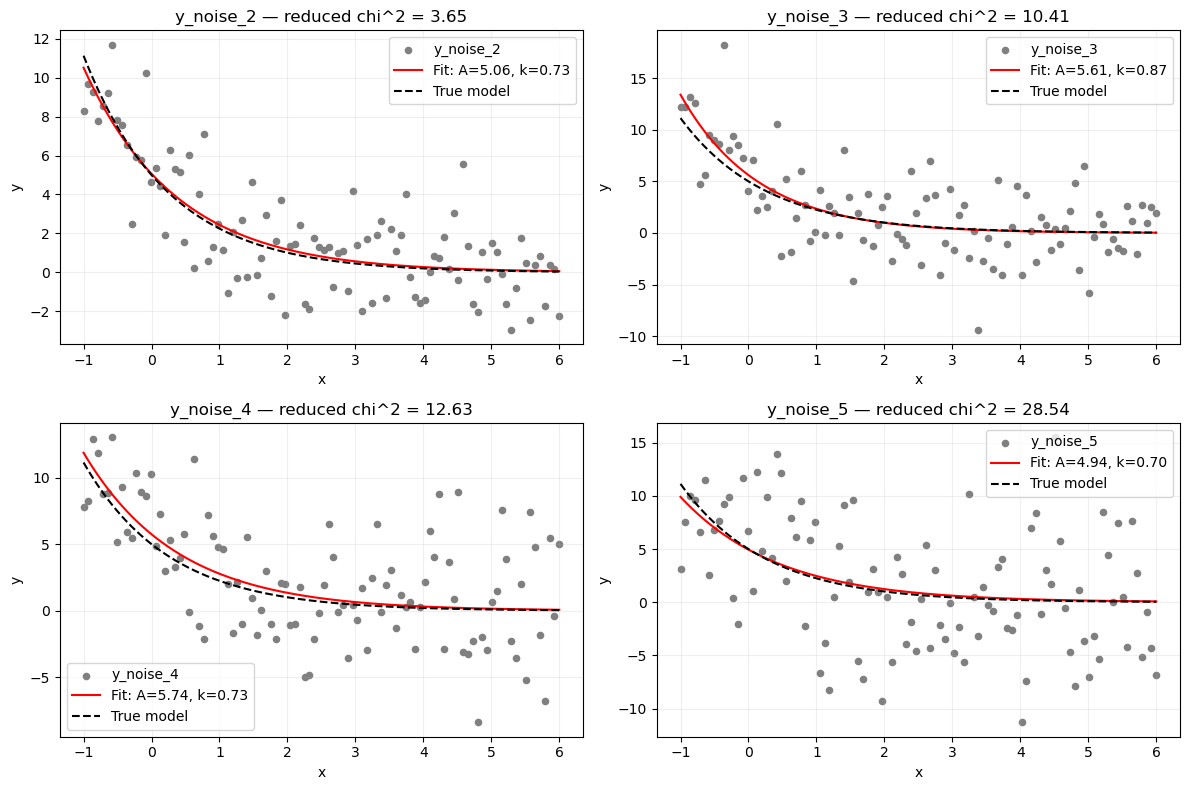

In [33]:
def fit_model(x, y, p0=[1.0,1.0]):
    popt, pcov = curve_fit(model, x, y, p0=p0)
    A_fit, k_fit = popt
    residuals = y - model(x, A_fit, k_fit)
    chi2 = np.sum(residuals**2)
    dof = len(x) - len(popt)
    chi2_reduced = chi2 / dof
    return {'A_fit': A_fit, 'k_fit': k_fit, 'chi2_red': chi2_reduced, 'pcov': pcov}

noise_cols = ['y_noise_1', 'y_noise_2', 'y_noise_3', 'y_noise_4', 'y_noise_5']

fig, axes = plt.subplots(2, 2, figsize=(12,8))
axes = axes.flatten()

results = []
for i, col in enumerate(noise_cols[1:5]): 
    y = df[col].values
    res = fit_model(x, y, p0=[1.0,1.0])
    results.append((col, res))
    ax = axes[i]
    x_plot = np.linspace(x.min(), x.max(), 300)
    ax.scatter(x, y, color='gray', s=20, label=f'{col}')
    ax.plot(x_plot, model(x_plot, res['A_fit'], res['k_fit']), 'r-', label=f'Fit: A={res["A_fit"]:.2f}, k={res["k_fit"]:.2f}')
    ax.plot(x_plot, model(x_plot, 5.0, 0.8), linestyle='--', color='k', label='True model')
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_title(f"{col} — reduced chi^2 = {res['chi2_red']:.2f}")
    ax.legend()
    ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

In [34]:
# 4
# - As noise increases, the red curve deviates more from the black dotted line, as the fit becomes less certain and higher noise creates larger scatter
# - The reduced chi-squared increases as noise increases as residuals become larger. 

In [35]:
# 2.4 - Save Your Results

In [36]:
full_results = []
for col in noise_cols:
    y = df[col].values
    res = fit_model(x, y, p0=[1.0,1.0])
    full_results.append({
        'Noise level': col,
        'A_fit': res['A_fit'],
        'k_fit': res['k_fit'],
        'Reduced_chi2': res['chi2_red']
    })

results_df = pd.DataFrame(full_results)
display(results_df)

results_df.to_csv("noisy_parameters.csv", index=False)
print("Saved noisy_parameters.csv")

,Noise level,A_fit,k_fit,Reduced_chi2
0,y_noise_1,4.714814,0.918308,0.790673
1,y_noise_2,5.063889,0.730396,3.649382
2,y_noise_3,5.609396,0.870372,10.410207
3,y_noise_4,5.738727,0.725965,12.626832
4,y_noise_5,4.943458,0.695012,28.538124


Saved noisy_parameters.csv
